# **Import Library**

In [1]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
import os, time, gc, psutil, pickle, random
import tensorflow as tf
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, cohen_kappa_score, log_loss,
    classification_report, confusion_matrix, roc_auc_score
)

# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [3]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Access the file in Google Drive
attack = '/content/drive/MyDrive/Dataset/ICUDatasetProcessed/Attack.csv'
environmentmonitoring= '/content/drive/MyDrive/Dataset/ICUDatasetProcessed/environmentMonitoring.csv'
patientmonitoring = '/content/drive/MyDrive/Dataset/ICUDatasetProcessed/patientMonitoring.csv'

attack_df = pd.read_csv(attack)
environment_df = pd.read_csv(environmentmonitoring)
patient_df = pd.read_csv(patientmonitoring)

df = pd.concat([attack_df, environment_df, patient_df], axis=0, ignore_index=True)

print(df.shape)
df

/tmp/ipykernel_1180/2125421305.py:6: DtypeWarning: Columns (26,28,35) have mixed types. Specify dtype option on import or set low_memory=False.
  attack_df = pd.read_csv(attack)
/tmp/ipykernel_1180/2125421305.py:8: DtypeWarning: Columns (26,28,35) have mixed types. Specify dtype option on import or set low_memory=False.
  patient_df = pd.read_csv(patientmonitoring)


(188694, 52)


,frame.time_delta,frame.time_relative,frame.len,ip.src,ip.dst,tcp.srcport,tcp.dstport,tcp.flags,tcp.time_delta,tcp.len,...,mqtt.qos,mqtt.retain,mqtt.topic,mqtt.topic_len,mqtt.ver,mqtt.willmsg_len,ip.proto,ip.ttl,class,label
0,0.000000,0.000000,74,10.16.120.44,10.16.120.72,56808,1883,0x00000002,0.000000,0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,64,Attack,1
1,0.000052,0.000052,74,10.16.120.72,10.16.120.44,1883,56808,0x00000012,0.000052,0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,64,Attack,1
2,0.000008,0.000060,74,10.16.120.44,10.16.120.72,56810,1883,0x00000002,0.000000,0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,64,Attack,1
3,0.000012,0.000072,74,10.16.120.72,10.16.120.44,1883,56810,0x00000012,0.000012,0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,64,Attack,1
4,0.000003,0.000075,74,10.16.120.44,10.16.120.72,56812,1883,0x00000002,0.000000,0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,64,Attack,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188689,0.000196,6611.037621,78,10.5.126.165,10.5.126.56,44993,1883,0x00000018,1.989358,10,...,0.0,0.0,ECG,3.0,0.0,0.0,6,64,patientMonitoring,0
188690,0.000172,6611.037793,77,10.5.126.147,10.5.126.56,38323,1883,0x00000018,1.989338,9,...,0.0,0.0,EMG,3.0,0.0,0.0,6,64,patientMonitoring,0
188691,0.000126,6611.037919,77,10.5.126.147,10.5.126.56,41889,1883,0x00000018,1.989337,9,...,0.0,0.0,EMG,3.0,0.0,0.0,6,64,patientMonitoring,0
188692,0.000146,6611.038065,77,10.5.126.167,10.5.126.56,35965,1883,0x00000018,1.989211,9,...,0.0,0.0,EMG,3.0,0.0,0.0,6,64,patientMonitoring,0


In [5]:
df = df.drop(columns=['class'])

In [7]:
# ---- ধাপ ১: class drop, inf/nan handle (আগের মতোই) ----
df = df.replace([np.inf, -np.inf], np.nan)
df.dropna(inplace=True)

# redundant columns বাদ
redundant_cols = ['tcp.connection.fin', 'tcp.connection.rst', 'frame.len', 'tcp.pdu.size', 'mqtt.conflags']
df = df.drop(columns=redundant_cols)

# ---- ধাপ ২: আগে train/test split করো (raw data-তেই, কোনো fit করার আগে) ----
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# ---- ধাপ ৩: categorical column গুলো encode করো (LabelEncoder শুধু train-এ fit, test-এ শুধু transform) ----
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.difference(['label'])
cat_cols = df.select_dtypes(include=['object']).columns.difference(['label'])

train_df[cat_cols] = train_df[cat_cols].astype(str)
test_df[cat_cols] = test_df[cat_cols].astype(str)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    # test set-এ unseen category থাকলে সেটাকে একটা নতুন label দাও (crash এড়াতে)
    test_df[col] = test_df[col].apply(lambda x: x if x in le.classes_ else 'UNKNOWN')
    le_classes = np.append(le.classes_, 'UNKNOWN')
    le.classes_ = le_classes
    test_df[col] = le.transform(test_df[col])
    encoders[col] = le

# ---- ধাপ ৪: এখন সব feature column (num + newly-encoded cat) একসাথে scale করো ----
all_feature_cols = list(num_cols) + list(cat_cols)  # label বাদে সব feature
all_feature_cols = [c for c in all_feature_cols if c not in ['ip.src', 'ip.dst']]  # partition key আলাদা রাখো

scaler = StandardScaler()
train_df[all_feature_cols] = scaler.fit_transform(train_df[all_feature_cols])   # শুধু train এ fit
test_df[all_feature_cols] = scaler.transform(test_df[all_feature_cols])          # test এ শুধু transform

print("Train shape:", train_df.shape, "Test shape:", test_df.shape)

Train shape: (150955, 46) Test shape: (37739, 46)


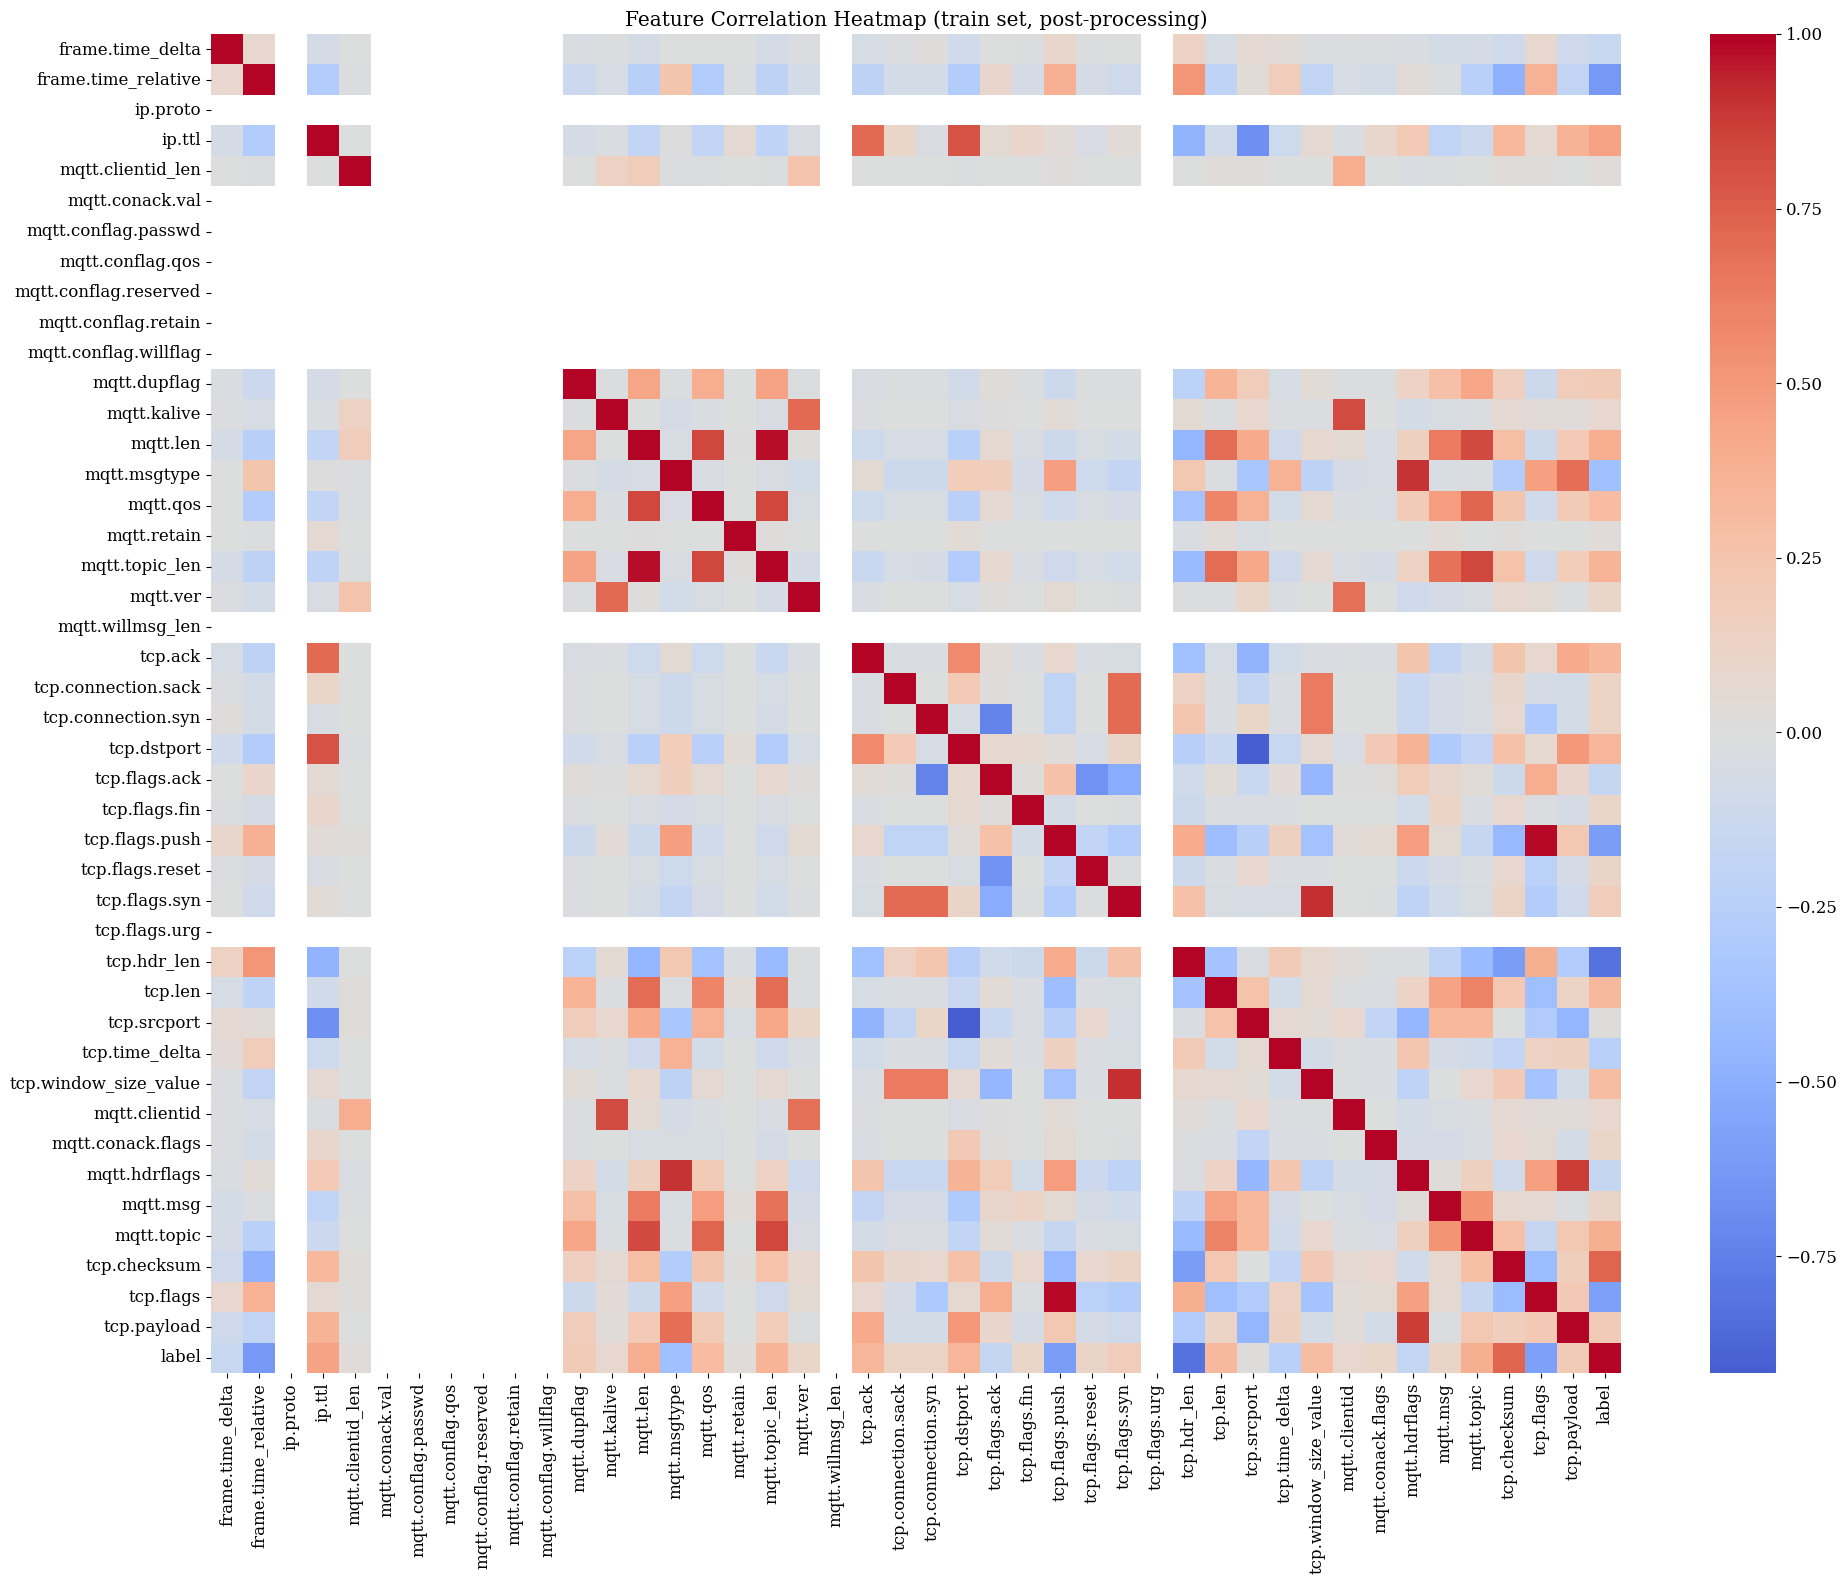

label                    1.000000
tcp.checksum             0.726079
ip.ttl                   0.451460
mqtt.len                 0.397903
mqtt.topic               0.385044
mqtt.topic_len           0.352343
tcp.dstport              0.346693
tcp.ack                  0.338384
tcp.len                  0.319433
mqtt.qos                 0.309704
tcp.window_size_value    0.300901
mqtt.dupflag             0.205485
tcp.payload              0.199174
tcp.flags.syn            0.168604
tcp.connection.syn       0.118794
tcp.connection.sack      0.118407
mqtt.msg                 0.111989
tcp.flags.reset          0.109912
mqtt.conack.flags        0.108339
tcp.flags.fin            0.108195
mqtt.ver                 0.107148
mqtt.kalive              0.085609
mqtt.clientid            0.080342
mqtt.retain              0.028431
mqtt.clientid_len        0.027283
tcp.srcport              0.015364
frame.time_delta        -0.152512
tcp.flags.ack           -0.161617
mqtt.hdrflags           -0.162611
tcp.time_delta

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

analysis_cols = all_feature_cols + ['label']  # ip.src/ip.dst বাদেই, যেহেতু client-partition key

plt.figure(figsize=(20, 16))
corr = train_df[analysis_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title("Feature Correlation Heatmap (train set, post-processing)")
plt.tight_layout()
plt.show()

label_corr = corr['label'].sort_values(ascending=False)
print(label_corr)

In [11]:
from sklearn.ensemble import RandomForestClassifier

X_check = train_df[all_feature_cols]
y_check = train_df['label']

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_check, y_check)

importance_df = pd.DataFrame({
    'feature': X_check.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance_df)

                  feature    importance
1     frame.time_relative  2.158301e-01
30            tcp.hdr_len  1.476170e-01
34  tcp.window_size_value  1.150204e-01
40           tcp.checksum  9.384005e-02
33         tcp.time_delta  9.027911e-02
32            tcp.srcport  5.543053e-02
26         tcp.flags.push  3.667707e-02
38               mqtt.msg  2.803386e-02
42            tcp.payload  2.517008e-02
37          mqtt.hdrflags  2.429204e-02
20                tcp.ack  2.160881e-02
23            tcp.dstport  2.098695e-02
3                  ip.ttl  1.958237e-02
31                tcp.len  1.906374e-02
14           mqtt.msgtype  1.720742e-02
39             mqtt.topic  1.691934e-02
41              tcp.flags  1.639109e-02
17         mqtt.topic_len  1.203495e-02
13               mqtt.len  9.244378e-03
0        frame.time_delta  6.772455e-03
15               mqtt.qos  4.343106e-03
18               mqtt.ver  1.035955e-03
35          mqtt.clientid  5.247250e-04
11           mqtt.dupflag  4.700602e-04


In [30]:
# ---- 3. High-correlation feature pairs খুঁজে বের করো (redundant feature চিহ্নিত করতে) ----
threshold = 0.9
corr_matrix = train_df[all_feature_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [(col, row, upper.loc[row, col])
                    for col in upper.columns
                    for row in upper.index
                    if upper.loc[row, col] > threshold]

print("High correlation pairs (potential redundant features):")
for pair in high_corr_pairs:
    print(pair)

High correlation pairs (potential redundant features):
('mqtt.topic_len', 'mqtt.len', np.float64(0.9774145081569771))
('tcp.srcport', 'tcp.dstport', np.float64(0.9175990852434536))
('tcp.window_size_value', 'tcp.flags.syn', np.float64(0.9030572942091042))
('tcp.flags', 'tcp.flags.push', np.float64(0.9816689708623995))


In [31]:
import numpy as np

NUM_CLIENTS = 5

partition_key = df['ip.src'].values
X = df.drop(columns=['label', 'ip.src', 'ip.dst']).values.astype(np.float32)
y = df['label'].values.astype(np.int64)

unique_ips = df['ip.src'].unique()
np.random.seed(42)
np.random.shuffle(unique_ips)
ip_groups = np.array_split(unique_ips, NUM_CLIENTS)

client_data = {}
for i, ips in enumerate(ip_groups):
    mask = df['ip.src'].isin(ips).values
    client_data[i] = (X[mask], y[mask])
    print(f"Client {i}: {mask.sum()} samples, attack ratio: {y[mask].mean():.2f}")

Client 0: 8063 samples, attack ratio: 0.00
Client 1: 26851 samples, attack ratio: 0.00
Client 2: 61915 samples, attack ratio: 0.66
Client 3: 15783 samples, attack ratio: 0.21
Client 4: 38343 samples, attack ratio: 0.51


In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss
from sklearn.utils.class_weight import compute_class_weight

INPUT_DIM = X_train_all.shape[1]

def create_model():
    model = models.Sequential([
        layers.Input(shape=(INPUT_DIM,)),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(2, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [33]:
def average_weights(weight_list, sample_counts):
    total_samples = sum(sample_counts)
    avg_weights = []
    for weights_at_layer in zip(*weight_list):
        weighted_layer = sum(w * (n / total_samples) for w, n in zip(weights_at_layer, sample_counts))
        avg_weights.append(weighted_layer)
    return avg_weights


def train_client(weights, X_c, y_c, local_epochs=1, batch_size=32):
    model = create_model()
    model.set_weights(weights)
    classes = np.unique(y_c)
    class_weight = None
    if len(classes) > 1:
        cw = compute_class_weight('balanced', classes=classes, y=y_c)
        class_weight = dict(zip(classes, cw))
    model.fit(X_c, y_c, epochs=local_epochs, batch_size=batch_size, verbose=0, class_weight=class_weight)
    return model.get_weights()


def compute_full_metrics(model, X_data, y_data):
    y_pred_proba = model.predict(X_data, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    acc = accuracy_score(y_data, y_pred)
    prec = precision_score(y_data, y_pred, zero_division=0)
    rec = recall_score(y_data, y_pred, zero_division=0)
    f1 = f1_score(y_data, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_data, y_pred_proba[:, 1])
    except ValueError:
        auc = float('nan')
    loss = log_loss(y_data, y_pred_proba, labels=[0, 1])

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1, 'auc': auc, 'loss': loss}

In [39]:
NUM_ROUNDS = 10
LOCAL_EPOCHS = 2

global_model = create_model()
global_weights = global_model.get_weights()
eval_model = create_model()

global_history = {'round': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1_score': [], 'auc': [], 'loss': []}
per_client_history = {cid: {'round': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1_score': [], 'auc': [], 'loss': []}
                       for cid in client_data.keys()}

for rnd in range(1, NUM_ROUNDS + 1):
    local_weights_list = []
    sample_counts = []

    for cid, (X_c, y_c) in client_data.items():
        updated_weights = train_client(global_weights, X_c, y_c, local_epochs=LOCAL_EPOCHS)
        local_weights_list.append(updated_weights)
        sample_counts.append(len(X_c))

        eval_model.set_weights(updated_weights)
        metrics = compute_full_metrics(eval_model, X_test, y_test)
        per_client_history[cid]['round'].append(rnd)
        for k, v in metrics.items():
            per_client_history[cid][k].append(v)

    global_weights = average_weights(local_weights_list, sample_counts)

    eval_model.set_weights(global_weights)
    g_metrics = compute_full_metrics(eval_model, X_test, y_test)
    global_history['round'].append(rnd)
    for k, v in g_metrics.items():
        global_history[k].append(v)

    print(f"Round {rnd}: Acc={g_metrics['accuracy']:.4f}, F1={g_metrics['f1_score']:.4f}, "
          f"AUC={g_metrics['auc']:.4f}, Loss={g_metrics['loss']:.4f}")

Round 1: Acc=0.9919, F1=0.9905, AUC=0.9986, Loss=0.0440
Round 2: Acc=0.9983, F1=0.9980, AUC=0.9989, Loss=0.0176
Round 3: Acc=0.9986, F1=0.9983, AUC=0.9991, Loss=0.0153
Round 4: Acc=0.9984, F1=0.9981, AUC=0.9998, Loss=0.0147
Round 5: Acc=0.9972, F1=0.9968, AUC=0.9998, Loss=0.0169
Round 6: Acc=0.9982, F1=0.9979, AUC=0.9996, Loss=0.0138
Round 7: Acc=0.9983, F1=0.9980, AUC=0.9993, Loss=0.0157
Round 8: Acc=0.9983, F1=0.9980, AUC=0.9993, Loss=0.0137
Round 9: Acc=0.9975, F1=0.9971, AUC=0.9993, Loss=0.0145
Round 10: Acc=0.9971, F1=0.9966, AUC=0.9993, Loss=0.0166


In [40]:
import pandas as pd

final_round_results = []
for cid in client_data.keys():
    last_idx = -1  # শেষ round
    row = {'client': cid}
    for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'auc', 'loss']:
        row[metric] = per_client_history[cid][metric][last_idx]
    final_round_results.append(row)

results_df = pd.DataFrame(final_round_results)
print(results_df.round(4))

   client  accuracy  precision  recall  f1_score     auc    loss
0       0    0.9713     0.9367  1.0000    0.9673  0.9990  0.0697
1       1    0.9281     0.8552  0.9999    0.9219  0.9963  0.6787
2       2    0.9954     0.9893  1.0000    0.9946  0.9993  0.0272
3       3    0.9740     0.9423  1.0000    0.9703  0.9994  0.0753
4       4    0.9983     0.9968  0.9991    0.9980  0.9992  0.0123


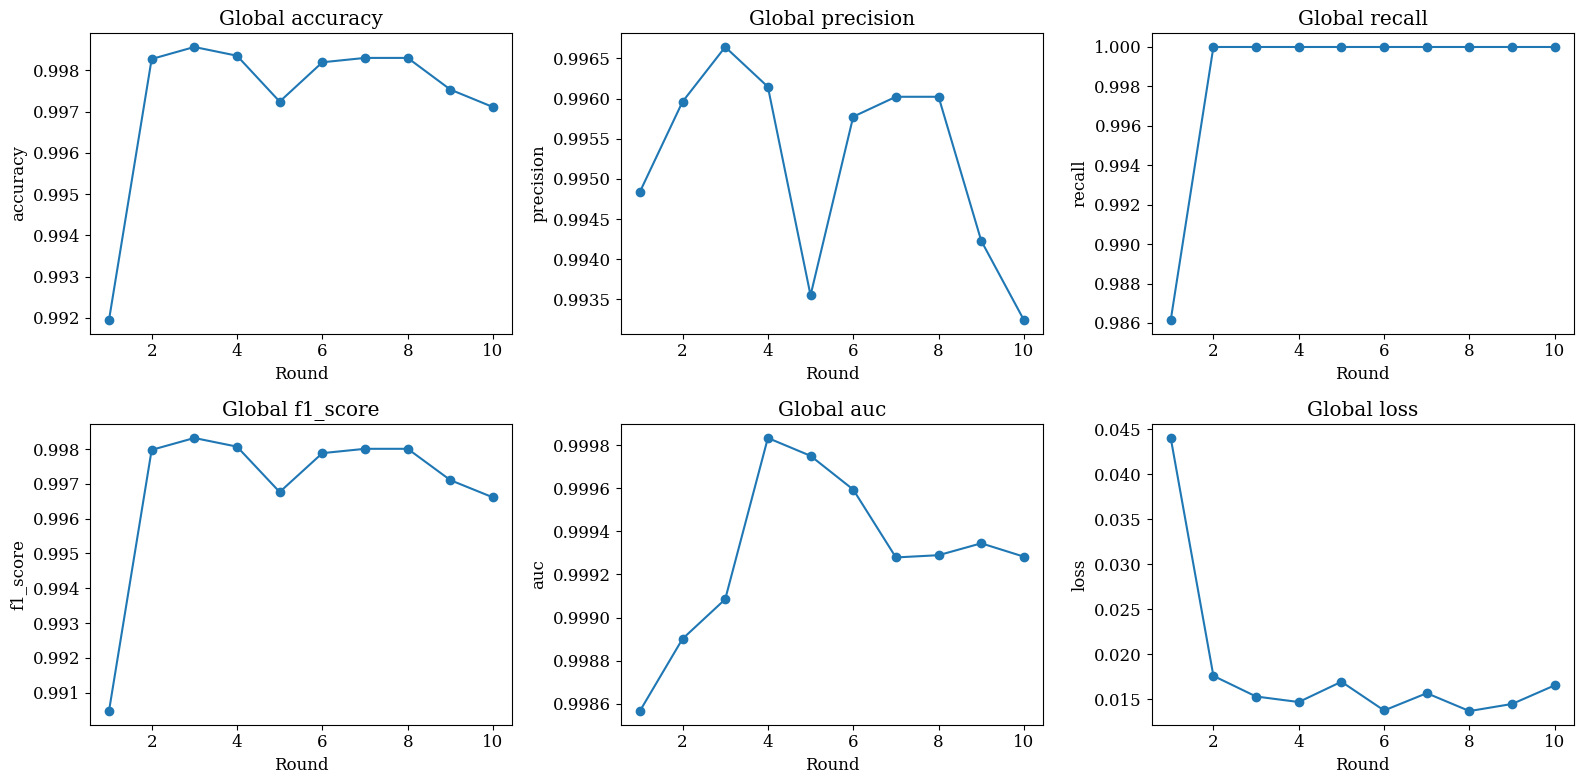

In [41]:
import matplotlib.pyplot as plt

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'auc', 'loss']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    axes[i].plot(global_history['round'], global_history[metric], marker='o', color='tab:blue')
    axes[i].set_title(f'Global {metric}')
    axes[i].set_xlabel('Round')
    axes[i].set_ylabel(metric)

plt.tight_layout()
plt.show()

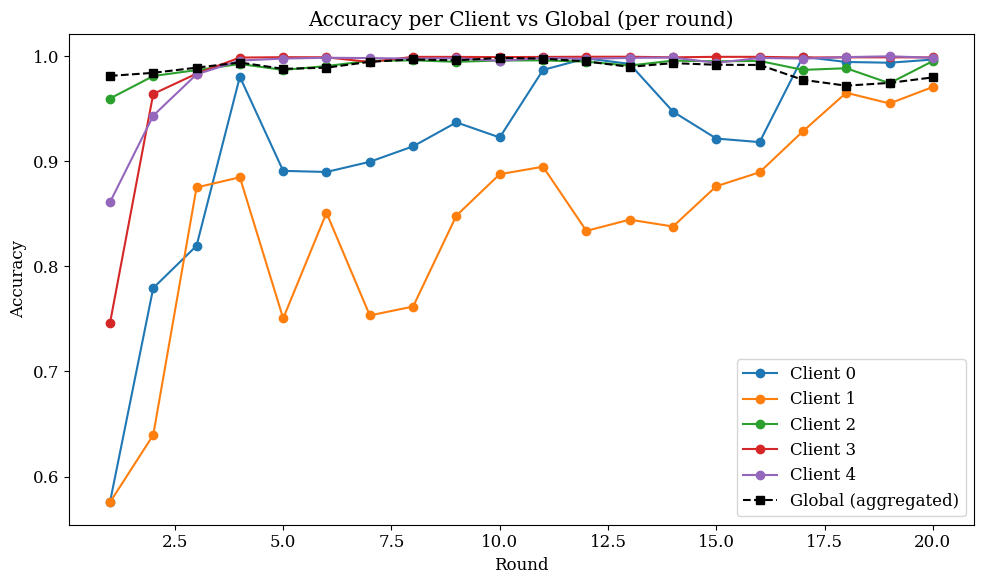

In [38]:
plt.figure(figsize=(10, 6))
for cid in client_data.keys():
    plt.plot(per_client_history[cid]['round'], per_client_history[cid]['accuracy'], marker='o', label=f'Client {cid}')
plt.plot(global_history['round'], global_history['accuracy'], marker='s', linestyle='--', color='black', label='Global (aggregated)')
plt.title('Accuracy per Client vs Global (per round)')
plt.xlabel('Round')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()